# Template

```
Majority Class Baseline
        ↓
TF-IDF + Logistic Regression        ← sparse features, linear model, diagnostic baseline
        ↓
TF-IDF + XGBoost                    ← non-linear baseline, still sparse
        ↓
GloVe/FastText + MLP                ← dense document-level features
        ↓
GloVe/FastText + CNN                ← sequential, local n-gram patterns
        ↓
GloVe/FastText + BiLSTM + Attention ← sequential, long-range dependencies
        ↓
Fine-tuned Transformer (BERT)       ← contextual embeddings, full fine-tuning
```

> **Key distinction:** TF-IDF feeds linear/tree models only. CNN and RNN receive token sequences → embedding matrix (GloVe/FastText). Transformers use their own subword tokenizer and built-in embeddings — feed raw (minimally cleaned) text.

---
# SECTION 0 — Environment Setup & Reproducibility

In [1]:
# ── 0.1 Imports ─────────────────────────────────────────────────────────────
import os, sys, json, time, warnings, logging
import random
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Sklearn
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    StratifiedKFold, train_test_split, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder
import joblib

# XGBoost
from xgboost import XGBClassifier

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback
)
from transformers.trainer_utils import get_last_checkpoint

# Embeddings
import gensim.downloader as api

# NLP
import nltk
import re, unicodedata
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download(["stopwords", "wordnet", "punkt"], quiet=True)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
print("Imports OK")

Imports OK


In [2]:
# ── 0.2 Global Configuration ─────────────────────────────────────────────────
CFG = {
    # ── Reproducibility
    "seed": 42,

    # ── Paths
    "data_dir":   Path("data/"),
    "output_dir": Path("outputs/"),
    "model_dir":  Path("models/"),
    "log_dir":    Path("logs/"),

    # ── Task  ← CHANGE ONLY THIS BLOCK between notebooks
    # Options: sentiment_analysis | abuse_detection | (any classification task)
    "task":       "abuse_detection",
    "text_col":   "text",
    "label_col":  "target",
    "num_labels": 3,

    # ── Split
    "test_size": 0.15,
    "val_size":  0.15,

    # ── Cross-validation
    "use_cv":   True,
    "cv_folds": 5,

    # ── TF-IDF
    "tfidf_word_ngrams": (1, 2),
    "use_char_ngrams":   True,
    "class_weight":      "balanced",

    # ── Embeddings
    "embedding_model": "glove-wiki-gigaword-100",  # or "fasttext-wiki-news-subwords-300"
    "embedding_dim":   100,
    "vocab_size":      30_000,
    "max_seq_len":     128,
    "pad_token":       "<PAD>",
    "unk_token":       "<UNK>",

    # ── Deep learning (CNN / BiLSTM / MLP)
    "dl_batch_size": 64,
    "dl_epochs":     20,
    "dl_lr":         1e-3,
    "dl_patience":   3,
    "dropout":       0.3,

    # ── CNN-specific
    "cnn_num_filters":  128,
    "cnn_kernel_sizes": [2, 3, 4],

    # ── BiLSTM-specific
    "lstm_hidden_dim": 128,
    "lstm_num_layers": 2,

    # ── Transformer
    "trf_model":  "bert-base-uncased",
    "max_len":    256,
    "batch_size": 16,
    "epochs":     5,
    "lr":         2e-5,

    # ── Device
    "device": (
        "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    )
}

#Create directories (uncomment to create folders)
for d in ["data_dir", "output_dir", "model_dir", "log_dir"]:
    CFG[d].mkdir(parents=True, exist_ok=True)

print(f"Task  : {CFG['task']}")
print(f"Labels: {CFG['num_labels']}")
print(f"Device: {CFG['device']}")

Task  : abuse_detection
Labels: 3
Device: mps


In [3]:
def set_seed(seed: int = 42):
    """Fix all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(CFG["seed"])
print("Seed set.")

Seed set.


---
# SECTION 1 — Data Loading & Inspection

In [4]:
# Example
url = "https://raw.githubusercontent.com/kmi-linguistics/trac-1/refs/heads/master/english/agr_en_train.csv"
df_raw = pd.read_csv(
    url,
    header=None,
    names=["id", "text", "target"]
)

df_raw.head()

,id,text,target
0,facebook_corpus_msr_1723796,Well said sonu..you have courage to stand agai...,OAG
1,facebook_corpus_msr_466073,"Most of Private Banks ATM's Like HDFC, ICICI e...",NAG
2,facebook_corpus_msr_1493901,"Now question is, Pakistan will adhere to this?",OAG
3,facebook_corpus_msr_405512,Pakistan is comprised of fake muslims who does...,OAG
4,facebook_corpus_msr_1521685,"??we r against cow slaughter,so of course it w...",NAG


In [5]:
print(f"Shape: {df_raw.shape}")
print("\n=== dtypes ===")
print(df_raw.dtypes)
print("\n=== nulls ===")
print(df_raw.isnull().sum())
print("\n=== label distribution ===")
print(df_raw[CFG["label_col"]].value_counts())

df_raw["text_len"] = df_raw[CFG["text_col"]].str.split().str.len()
print("\n=== text length (words) ===")
print(df_raw["text_len"].describe().round(1))

Shape: (12000, 3)

=== dtypes ===
id        str
text      str
target    str
dtype: object

=== nulls ===
id        0
text      0
target    0
dtype: int64

=== label distribution ===
target
NAG    5052
CAG    4240
OAG    2708
Name: count, dtype: int64

=== text length (words) ===
count    12000.0
mean        24.8
std         37.5
min          1.0
25%         11.0
50%         16.0
75%         27.0
max       1126.0
Name: text_len, dtype: float64


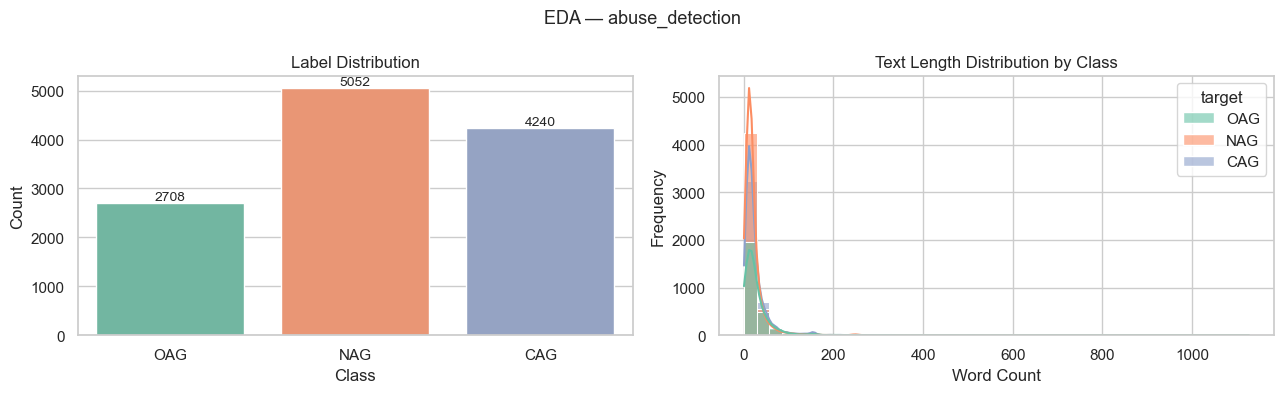

In [6]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(
    data=df_raw,
    x=CFG["label_col"],
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("Label Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=10)

sns.histplot(
    data=df_raw,
    x="text_len",
    hue=CFG["label_col"],
    bins=40,
    kde=True,
    palette="Set2",
    alpha=0.6,
    ax=axes[1]
)

axes[1].set_title("Text Length Distribution by Class")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.suptitle(f"EDA — {CFG['task']}", fontsize=13)
plt.tight_layout()
plt.savefig(CFG["output_dir"] / "eda_overview.png", dpi=120)
plt.show()

---
# SECTION 2 — Preprocessing

In [7]:
# ── 2.1 Preprocessing Functions ──────────────────────────────────────────────
STOP = set(stopwords.words("english"))  # [TASK-SPECIFIC] change language if needed
lemmatizer = WordNetLemmatizer()

def normalize_text(text: str) -> str:
    """
    Minimal cleaning — used as input for Transformers.
    Keeps punctuation and casing information the subword tokenizer relies on.
    """
    text = str(text).lower()
    text = unicodedata.normalize("NFKD", text)
    text = re.sub(r"http\S+|www\S+", " ", text)          # URLs
    text = re.sub(r"@\w+|#\w+", " ", text)                # mentions / hashtags
    text = re.sub(r"[^a-zA-Z0-9\s!?.,\'\']", " ", text)   # special chars
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess(text: str,
               remove_stopwords: bool = True,
               lemmatize: bool = True) -> str:
    """
    Full cleaning — used for classical ML and embedding-based models.
    Applies stopword removal and lemmatization on top of normalize_text.
    """
    text   = normalize_text(text)
    tokens = text.split()
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP]
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)


# Smoke test
sample = "This is a GREAT movie!! http://example.com @user #review"
print("Raw         :", sample)
print("Normalized  :", normalize_text(sample))
print("Preprocessed:", preprocess(sample))

Raw         : This is a GREAT movie!! http://example.com @user #review
Normalized  : this is a great movie!!
Preprocessed: great movie!!


In [8]:
# ── 2.2 Apply Preprocessing ───────────────────────────────────────────────────
#   text_clean → classical ML + CNN/RNN (full cleaning)
#   text_raw   → Transformers (minimal cleaning; BERT handles the rest)

df = df_raw.copy()
tqdm.pandas(desc="Preprocessing")
df["text_clean"] = df[CFG["text_col"]].progress_apply(preprocess)
df["text_raw"]   = df[CFG["text_col"]].progress_apply(normalize_text)

# Drop missing / duplicate
df = df.dropna(subset=[CFG["text_col"], CFG["label_col"]])
df = df.drop_duplicates(subset=[CFG["text_col"]])
print(f"Final dataset size: {len(df)}")

# Encode Labels
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df[CFG["label_col"]])
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
df.head(1)

Preprocessing:   0%|          | 0/12000 [00:00<?, ?it/s]

Preprocessing:   0%|          | 0/12000 [00:00<?, ?it/s]

Final dataset size: 11645
Class mapping: {'CAG': np.int64(0), 'NAG': np.int64(1), 'OAG': np.int64(2)}


,id,text,target,text_len,text_clean,text_raw,label_enc
0,facebook_corpus_msr_1723796,Well said sonu..you have courage to stand agai...,OAG,11,well said sonu..you courage stand dadagiri muslim,well said sonu..you have courage to stand agai...,2


---
# SECTION 3 — Train / Validation / Test Split

In [9]:
# ── 3.1 Stratified Split ──────────────────────────────────────────────────────
df_train_full, df_test = train_test_split(
    df,
    test_size=CFG["test_size"],
    random_state=CFG["seed"],
    stratify=df["label_enc"],
)

df_train, df_val = train_test_split(
    df_train_full,
    test_size=CFG["val_size"] / (1 - CFG["test_size"]),
    random_state=CFG["seed"],
    stratify=df_train_full["label_enc"],
)

# Reset indices — important for DataLoader alignment
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

# ── 3.2 Shared Arrays ────────────────────────────────────────────────────────
# Classical ML & CNN/RNN → preprocessed text
X_train = df_train["text_clean"].values
X_val   = df_val["text_clean"].values
X_test  = df_test["text_clean"].values

# Transformers → minimally cleaned text
X_train_raw = df_train["text_raw"].values
X_val_raw   = df_val["text_raw"].values
X_test_raw  = df_test["text_raw"].values

y_train = df_train["label_enc"].values
y_val   = df_val["label_enc"].values
y_test  = df_test["label_enc"].values

# ── 3.3 Cross-Validation Object ──────────────────────────────────────────────
cv = StratifiedKFold(
    n_splits=CFG["cv_folds"],
    shuffle=True,
    random_state=CFG["seed"]
)

Train: 8151 | Val: 1747 | Test: 1747


---
# SECTION 4 — Evaluation Utilities

In [10]:
# ── 4.1 Results Registry ─────────────────────────────────────────────────────
RESULTS = {}  # {"ModelName | split": {metric: value}}


# ── 4.2 Classification Evaluation ────────────────────────────────────────────
def evaluate_clf(model_name: str, y_true, y_pred,
                 y_prob=None, label_encoder=None, split: str = "test") -> dict:
    """
    Computes and prints classification metrics; stores them in RESULTS.

    Parameters
    ----------
    model_name    : display name for the model
    y_true        : ground-truth encoded labels
    y_pred        : predicted encoded labels
    y_prob        : class probabilities shape (n, 2) — binary tasks only, for ROC-AUC
    label_encoder : fitted sklearn LabelEncoder (for human-readable class names)
    split         : "val" or "test"

    Returns
    -------
    dict of computed metrics
    """
    acc       = accuracy_score(y_true, y_pred)
    f1_macro  = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weight = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    auc = (
        roc_auc_score(y_true, y_prob[:, 1])
        if (y_prob is not None and y_prob.shape[1] == 2) else None
    )

    print(f"\n{'='*55}")
    print(f"  {model_name} | {split.upper()}")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weight:.4f}")
    if auc is not None:
        print(f"  ROC-AUC       : {auc:.4f}")

    class_names = label_encoder.classes_.tolist() if label_encoder else None
    print()
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    metrics = {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weight}
    if auc is not None:
        metrics["roc_auc"] = auc

    RESULTS[f"{model_name} | {split}"] = metrics
    return metrics


# ── 4.3 Confusion Matrix Plot ─────────────────────────────────────────────────
def plot_confusion_matrix_clf(y_true, y_pred, model_name: str, label_encoder=None):
    """
    Plots raw-count and row-normalised confusion matrices side by side.
    Saves figure to outputs/.
    """
    cm     = confusion_matrix(y_true, y_pred)
    labels = label_encoder.classes_ if label_encoder else np.unique(y_true)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, title, fmt in zip(
        axes, [cm, cm_norm], ["Raw Counts", "Normalized"], ["d", ".2f"]
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(title)

    plt.suptitle(f"Confusion Matrix — {model_name}", fontsize=13)
    plt.tight_layout()
    fname = CFG["output_dir"] / f"cm_{model_name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=120)
    plt.show()


# ── 4.4 Training History Plot ────────────────────────────────────────────────
def plot_history(history: dict, model_name: str):
    """
    Plots loss and F1-macro curves over epochs.

    Expected history keys:
        "train_loss"   : list[float]
        "val_loss"     : list[float]
        "val_f1_macro" : list[float]
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="Train", marker="o")
    axes[0].plot(history["val_loss"],   label="Val",   marker="o")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["val_f1_macro"], marker="o", color="orange")
    axes[1].set_title("Val F1 Macro")
    axes[1].set_xlabel("Epoch")

    plt.suptitle(model_name, fontsize=13)
    plt.tight_layout()
    fname = CFG["output_dir"] / f"history_{model_name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=120)
    plt.show()


# ── 4.5 Results Summary Table ────────────────────────────────────────────────
def print_results_table():
    """Prints a formatted comparison table of all models stored in RESULTS."""
    if not RESULTS:
        print("RESULTS is empty — run evaluate_clf first.")
        return

    all_cols = sorted({k for v in RESULTS.values() for k in v.keys()})
    header = f"{'Model':<35}" + "".join(f"{c:>14}" for c in all_cols)
    sep = "=" * len(header)
    print(f"\n{sep}\n{header}\n{sep}")
    for name, metrics in RESULTS.items():
        row = f"{name:<35}" + "".join(
            f"{metrics.get(c, float('nan')):>14.4f}" for c in all_cols
        )
        print(row)
    print(sep)


print("Evaluation utilities ready.")

Evaluation utilities ready.


---
# SECTION 5 — Baseline Models (Classical ML / Sparse Features)

Pipeline: **Majority Class → TF-IDF + LogReg → TF-IDF + XGBoost**  
All models use `X_train` / `X_test` (fully preprocessed `text_clean`).

In [11]:
# ── 5.1 Majority Class Baseline ───────────────────────────────────────────────
dummy = DummyClassifier(strategy="most_frequent", random_state=CFG["seed"])
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

evaluate_clf("Majority Baseline", y_test, dummy_preds, label_encoder=le)


  Majority Baseline | TEST
  Accuracy      : 0.4161
  F1 (macro)    : 0.1959
  F1 (weighted) : 0.2446

              precision    recall  f1-score   support

         CAG       0.00      0.00      0.00       625
         NAG       0.42      1.00      0.59       727
         OAG       0.00      0.00      0.00       395

    accuracy                           0.42      1747
   macro avg       0.14      0.33      0.20      1747
weighted avg       0.17      0.42      0.24      1747



{'accuracy': 0.41614195764167144,
 'f1_macro': 0.19590406898410131,
 'f1_weighted': 0.24457170833103892}

In [12]:
# ── 5.2 TF-IDF Vectoriser Helper ──────────────────────────────────────────────
def build_tfidf(word_ngrams=(1, 2), char_ngrams=True, max_features=100_000):
    """
    Fits word-level (and optionally char-level) TF-IDF on X_train;
    transforms X_val and X_test.

    Returns
    -------
    X_tr, X_va, X_te : sparse matrices
    vecs             : tuple of fitted vectorisers
    """
    from scipy.sparse import hstack

    word_vec = TfidfVectorizer(
        analyzer="word", ngram_range=word_ngrams,
        max_features=max_features, sublinear_tf=True, min_df=2
    )
    X_tr_w = word_vec.fit_transform(X_train)
    X_va_w = word_vec.transform(X_val)
    X_te_w = word_vec.transform(X_test)

    if char_ngrams:
        char_vec = TfidfVectorizer(
            analyzer="char_wb", ngram_range=(3, 5),
            max_features=max_features // 2, sublinear_tf=True, min_df=2
        )
        X_tr_c = char_vec.fit_transform(X_train)
        X_va_c = char_vec.transform(X_val)
        X_te_c = char_vec.transform(X_test)
        return (
            hstack([X_tr_w, X_tr_c]),
            hstack([X_va_w, X_va_c]),
            hstack([X_te_w, X_te_c]),
            (word_vec, char_vec)
        )

    return X_tr_w, X_va_w, X_te_w, (word_vec,)


X_tr_tfidf, X_va_tfidf, X_te_tfidf, tfidf_vecs = build_tfidf(
    word_ngrams=CFG["tfidf_word_ngrams"],
    char_ngrams=CFG["use_char_ngrams"]
)
print(f"TF-IDF feature dim: {X_tr_tfidf.shape[1]:,}")

TF-IDF feature dim: 65,550


[LogReg CV] F1-macro: 0.5390 ± 0.0127

  TF-IDF + LogReg | VAL
  Accuracy      : 0.5610
  F1 (macro)    : 0.5467
  F1 (weighted) : 0.5616

              precision    recall  f1-score   support

         CAG       0.49      0.48      0.48       625
         NAG       0.67      0.66      0.67       728
         OAG       0.48      0.50      0.49       394

    accuracy                           0.56      1747
   macro avg       0.55      0.55      0.55      1747
weighted avg       0.56      0.56      0.56      1747


  TF-IDF + LogReg | TEST
  Accuracy      : 0.5667
  F1 (macro)    : 0.5562
  F1 (weighted) : 0.5674

              precision    recall  f1-score   support

         CAG       0.51      0.49      0.50       625
         NAG       0.66      0.65      0.66       727
         OAG       0.49      0.54      0.52       395

    accuracy                           0.57      1747
   macro avg       0.55      0.56      0.56      1747
weighted avg       0.57      0.57      0.57      174

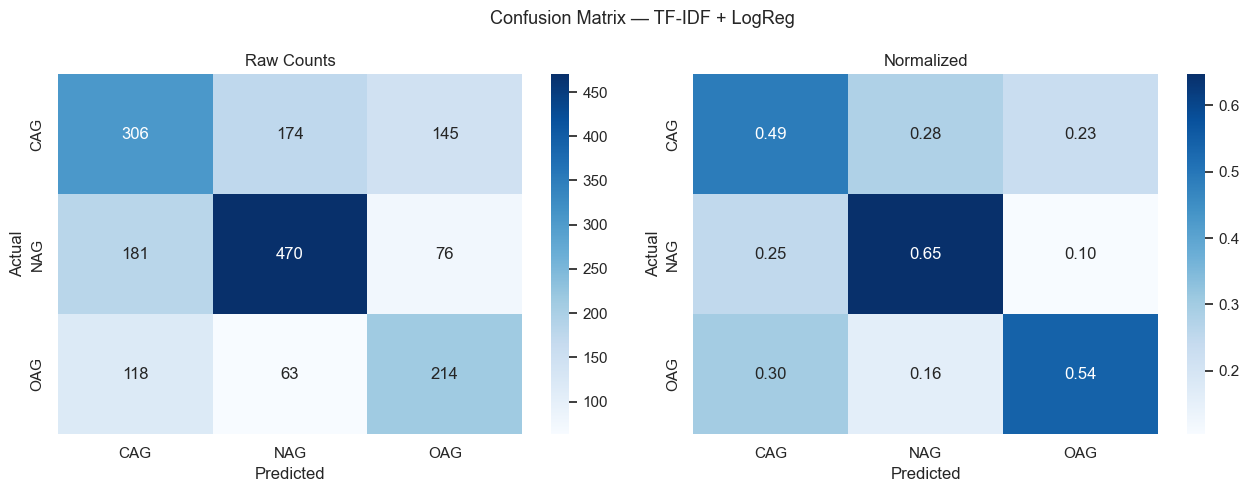

['models/logreg.pkl']

In [13]:
# ── 5.3 TF-IDF + Logistic Regression ─────────────────────────────────────────
logreg = LogisticRegression(
    max_iter=1000, C=1.0,
    class_weight=CFG["class_weight"],
    solver="saga",
    random_state=CFG["seed"]
)

if CFG["use_cv"]:
    cv_scores = cross_val_score(
        logreg, X_tr_tfidf, y_train,
        cv=cv, scoring="f1_macro", n_jobs=-1
    )
    print(f"[LogReg CV] F1-macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

logreg.fit(X_tr_tfidf, y_train)

evaluate_clf("TF-IDF + LogReg", y_val,
             logreg.predict(X_va_tfidf), label_encoder=le, split="val")
evaluate_clf("TF-IDF + LogReg", y_test,
             logreg.predict(X_te_tfidf),
             logreg.predict_proba(X_te_tfidf), label_encoder=le)
plot_confusion_matrix_clf(y_test, logreg.predict(X_te_tfidf), "TF-IDF + LogReg", le)

joblib.dump(logreg, CFG["model_dir"] / "logreg.pkl")

[XGBoost CV] F1-macro: 0.5188 ± 0.0152

  TF-IDF + XGBoost | VAL
  Accuracy      : 0.5392
  F1 (macro)    : 0.5061
  F1 (weighted) : 0.5285

              precision    recall  f1-score   support

         CAG       0.46      0.46      0.46       625
         NAG       0.60      0.72      0.65       728
         OAG       0.52      0.33      0.40       394

    accuracy                           0.54      1747
   macro avg       0.53      0.50      0.51      1747
weighted avg       0.53      0.54      0.53      1747


  TF-IDF + XGBoost | TEST
  Accuracy      : 0.5570
  F1 (macro)    : 0.5241
  F1 (weighted) : 0.5455

              precision    recall  f1-score   support

         CAG       0.50      0.47      0.48       625
         NAG       0.60      0.75      0.67       727
         OAG       0.54      0.35      0.42       395

    accuracy                           0.56      1747
   macro avg       0.55      0.52      0.52      1747
weighted avg       0.55      0.56      0.55      

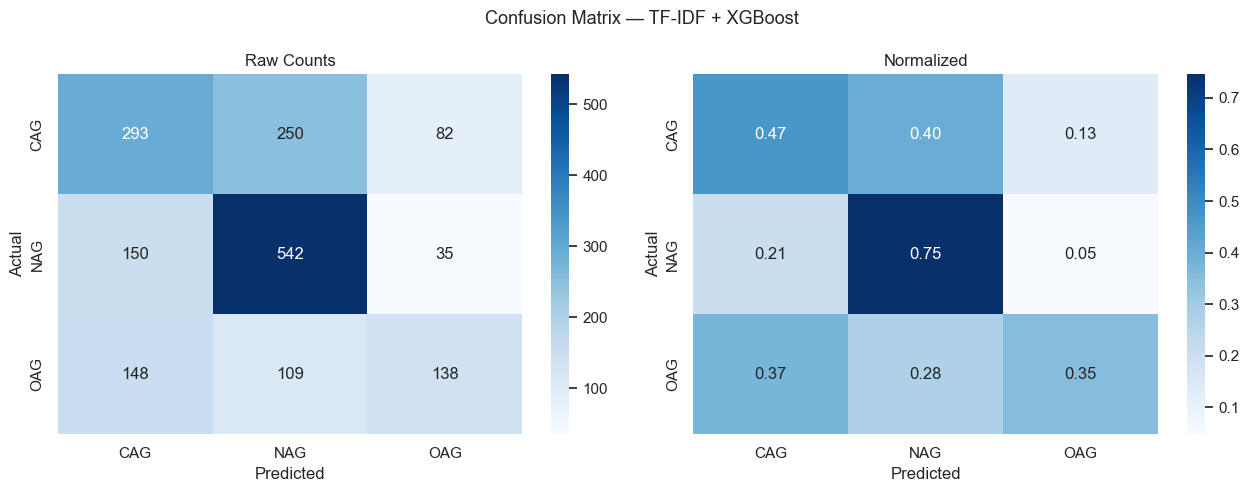

['models/xgboost.pkl']

In [14]:
# ── 5.4 TF-IDF + XGBoost ──────────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=CFG["seed"], n_jobs=-1, verbosity=0
)

if CFG["use_cv"]:
    xgb_cv = cross_val_score(
        xgb, X_tr_tfidf, y_train,
        cv=cv, scoring="f1_macro", n_jobs=-1
    )
    print(f"[XGBoost CV] F1-macro: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")

xgb.fit(X_tr_tfidf, y_train,
        eval_set=[(X_va_tfidf, y_val)], verbose=False)

xgb_test_preds = xgb.predict(X_te_tfidf)
evaluate_clf("TF-IDF + XGBoost", y_val,
             xgb.predict(X_va_tfidf), label_encoder=le, split="val")
evaluate_clf("TF-IDF + XGBoost", y_test,
             xgb_test_preds, xgb.predict_proba(X_te_tfidf), label_encoder=le)
plot_confusion_matrix_clf(y_test, xgb_test_preds, "TF-IDF + XGBoost", le)

joblib.dump(xgb, CFG["model_dir"] / "xgboost.pkl")

---
# SECTION 6 — Static Embeddings (GloVe / FastText)

Builds a vocabulary from the training set and creates a fixed embedding matrix  
shared by all deep learning models (MLP, CNN, BiLSTM).

In [15]:
# ── 6.1 Vocabulary Builder ────────────────────────────────────────────────────
def build_vocab(texts, max_vocab: int = 30_000,
                pad_token: str = "<PAD>", unk_token: str = "<UNK>") -> dict:
    """
    Builds word → index mapping from tokenised training texts.
    Index 0 = PAD (all-zeros row), Index 1 = UNK.
    """
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())

    vocab = {pad_token: 0, unk_token: 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab


vocab = build_vocab(
    X_train,
    max_vocab=CFG["vocab_size"],
    pad_token=CFG["pad_token"],
    unk_token=CFG["unk_token"]
)
print(f"Vocabulary size: {len(vocab):,}")

Vocabulary size: 25,183


In [16]:
# ── 6.2 Embedding Matrix ──────────────────────────────────────────────────────
def load_embedding_matrix(vocab: dict, model_name: str, embed_dim: int) -> np.ndarray:
    """
    Downloads a pre-trained gensim embedding model and builds a numpy matrix
    aligned with `vocab`. Unknown words get random uniform initialisations.

    Parameters
    ----------
    vocab      : {word: index} mapping
    model_name : gensim key (e.g. "glove-wiki-gigaword-100")
    embed_dim  : embedding dimensionality

    Returns
    -------
    np.ndarray of shape (vocab_size, embed_dim)
    """
    print(f"Loading {model_name} ...")
    wv = api.load(model_name)

    matrix = np.zeros((len(vocab), embed_dim), dtype=np.float32)
    hits = misses = 0
    for word, idx in vocab.items():
        if word in wv:
            matrix[idx] = wv[word]
            hits += 1
        else:
            matrix[idx] = np.random.uniform(-0.25, 0.25, embed_dim)
            misses += 1

    matrix[0] = 0.0  # PAD stays all-zeros
    print(f"Coverage: {hits/(hits+misses)*100:.1f}%  (hits={hits}, misses={misses})")
    return matrix


embedding_matrix = load_embedding_matrix(
    vocab, CFG["embedding_model"], CFG["embedding_dim"]
)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

INFO:gensim.models.keyedvectors:loading projection weights from /Users/georgijkutivadze/gensim-data/glove-wiki-gigaword-100/glove-wiki-gigaword-100.gz


Loading glove-wiki-gigaword-100 ...


INFO:gensim.utils:KeyedVectors lifecycle event {'msg': 'loaded (400000, 100) matrix of type float32 from /Users/georgijkutivadze/gensim-data/glove-wiki-gigaword-100/glove-wiki-gigaword-100.gz', 'binary': False, 'encoding': 'utf8', 'datetime': '2026-02-22T12:00:18.423537', 'gensim': '4.4.0', 'python': '3.11.11 | packaged by conda-forge | (main, Dec  5 2024, 08:47:03) [Clang 18.1.8 ]', 'platform': 'macOS-26.3-arm64-arm-64bit', 'event': 'load_word2vec_format'}


Coverage: 47.0%  (hits=11840, misses=13343)
Embedding matrix shape: (25183, 100)


In [17]:
# ── 6.3 Text → Padded Token-ID Sequences ─────────────────────────────────────
def texts_to_sequences(texts, vocab: dict, max_len: int,
                       unk_token: str = "<UNK>") -> np.ndarray:
    """
    Converts a list of strings to a (N, max_len) int32 numpy array.
    Truncates long sequences; pads short ones with 0 (PAD index).
    """
    unk_idx = vocab.get(unk_token, 1)
    seqs = np.zeros((len(texts), max_len), dtype=np.int32)
    for i, text in enumerate(texts):
        tokens = str(text).split()[:max_len]
        for j, tok in enumerate(tokens):
            seqs[i, j] = vocab.get(tok, unk_idx)
    return seqs


seq_train = texts_to_sequences(X_train, vocab, CFG["max_seq_len"])
seq_val   = texts_to_sequences(X_val,   vocab, CFG["max_seq_len"])
seq_test  = texts_to_sequences(X_test,  vocab, CFG["max_seq_len"])

print(f"seq_train: {seq_train.shape} | seq_val: {seq_val.shape} | seq_test: {seq_test.shape}")

seq_train: (8151, 128) | seq_val: (1747, 128) | seq_test: (1747, 128)


In [18]:
# ── 6.4 PyTorch Dataset & DataLoaders ────────────────────────────────────────
class TextSequenceDataset(Dataset):
    """
    Wraps padded token-ID sequences and integer class labels for classification.

    Parameters
    ----------
    sequences : np.ndarray shape (N, max_len)
    labels    : np.ndarray shape (N,) — integer class indices
    """
    def __init__(self, sequences: np.ndarray, labels: np.ndarray):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels    = torch.tensor(labels,    dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


def make_loaders(seq_tr, y_tr, seq_va, y_va, seq_te, y_te,
                 batch_size: int = 64):
    """Creates train / val / test DataLoaders."""
    loader_train = DataLoader(TextSequenceDataset(seq_tr, y_tr),
                              batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    loader_val   = DataLoader(TextSequenceDataset(seq_va, y_va),
                              batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    loader_test  = DataLoader(TextSequenceDataset(seq_te, y_te),
                              batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return loader_train, loader_val, loader_test


loader_train, loader_val, loader_test = make_loaders(
    seq_train, y_train, seq_val, y_val, seq_test, y_test,
    batch_size=CFG["dl_batch_size"]
)
print("DataLoaders ready.")

DataLoaders ready.


---
# SECTION 7 — Shared Deep Learning Training Loop

One `train_model()` function used by **MLP, CNN, and BiLSTM**.  
Loss: `CrossEntropyLoss`. Monitoring metric: `F1-macro` (higher = better).

In [19]:
# ── 7.0 Logging Setup ─────────────────────────────────────────────────────────
def get_logger(model_name: str) -> logging.Logger:
    log_path = CFG["log_dir"] / f"{CFG['task']}_{model_name.replace(' ', '_')}.log"

    logger = logging.getLogger(model_name)
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()
    logger.propagate = False

    fh = logging.FileHandler(log_path, mode="w", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(logging.Formatter(
        "%(asctime)s | %(levelname)-8s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    ))

    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO)
    ch.setFormatter(logging.Formatter("%(message)s"))

    logger.addHandler(fh)
    logger.addHandler(ch)
    return logger


# ── 7.1 Single Epoch Helpers ──────────────────────────────────────────────────
def _train_epoch(model, loader, optimizer, criterion, device):
    """One training pass. Returns average cross-entropy loss."""
    model.train()
    total_loss = 0.0
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(seqs), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * seqs.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def _eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        logits = model(seqs)
        total_loss += criterion(logits, labels).item() * seqs.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, f1_macro, np.array(all_preds)


# ── 7.2 Main Training Loop ────────────────────────────────────────────────────
def train_model(model, loader_tr, loader_va, model_name: str,
                epochs: int = 20, lr: float = 1e-3,
                patience: int = 3, device: str = "cpu",
                resume: bool = True) -> dict:
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

    logger = get_logger(model_name)
    tb_dir = CFG["log_dir"] / "tensorboard" / f"{CFG['task']}_{model_name.replace(' ', '_')}"
    writer = SummaryWriter(log_dir=tb_dir)

    history    = {"train_loss": [], "val_loss": [], "val_f1_macro": []}
    best_f1    = -np.inf
    no_improve = 0
    start_epoch = 1

    # --- checkpoint paths
    safe_name = model_name.replace(" ", "_")
    ckpt_dir = CFG["model_dir"] / safe_name
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    best_ckpt_path = ckpt_dir / "best.pt"
    last_ckpt_path = ckpt_dir / "last.pt"

    # --- optional resume
    if resume and last_ckpt_path.exists():
        ckpt = torch.load(last_ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])
        history = ckpt.get("history", history)
        best_f1 = ckpt.get("best_f1", best_f1)
        no_improve = ckpt.get("no_improve", 0)
        start_epoch = ckpt.get("epoch", 0) + 1
        logger.info(f"Resumed from {last_ckpt_path} (epoch={start_epoch-1}, best_f1={best_f1:.4f})")

    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()
        tr_loss           = _train_epoch(model, loader_tr, optimizer, criterion, device)
        va_loss, va_f1, _ = _eval_epoch(model, loader_va, criterion, device)
        elapsed           = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_f1_macro"].append(va_f1)
        scheduler.step(va_f1)

        writer.add_scalars("loss", {"train": tr_loss, "val": va_loss}, epoch)
        writer.add_scalar("val/f1_macro", va_f1, epoch)
        writer.add_scalar("train/lr", optimizer.param_groups[0]["lr"], epoch)

        # always save LAST checkpoint (for recovery)
        last_payload = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_f1": best_f1,
            "no_improve": no_improve,
            "history": history,
            "model_name": model_name,
            "task": CFG["task"],
        }
        torch.save(last_payload, last_ckpt_path)

        # save BEST checkpoint
        if va_f1 > best_f1:
            best_f1 = va_f1
            no_improve = 0
            best_payload = {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "best_f1": best_f1,
                "history": history,
                "model_name": model_name,
                "task": CFG["task"],
            }
            torch.save(best_payload, best_ckpt_path)
            tag = " ✓  <-- new best"
        else:
            no_improve += 1
            tag = ""

        logger.info(
            f"Epoch {epoch:>3}/{epochs} | tr_loss={tr_loss:.4f} | "
            f"va_loss={va_loss:.4f} | val_f1={va_f1:.4f} | {elapsed:.1f}s{tag}"
        )

        if no_improve >= patience:
            logger.info(f"Early stopping triggered at epoch {epoch}.")
            break

    # restore BEST weights from disk
    if best_ckpt_path.exists():
        best_ckpt = torch.load(best_ckpt_path, map_location=device)
        model.load_state_dict(best_ckpt["model_state"])
        logger.info(f"Restored best checkpoint | val_f1={best_ckpt['best_f1']:.4f} | path={best_ckpt_path}")

    writer.close()
    logger.info("Training complete.")
    return history


# ── 7.3 Batch Prediction Helper ───────────────────────────────────────────────
@torch.no_grad()
def predict(model, loader, device: str = "cpu") -> np.ndarray:
    model.eval()
    all_preds = []
    for seqs, _ in loader:
        all_preds.extend(model(seqs.to(device)).argmax(dim=1).cpu().numpy())
    return np.array(all_preds)


print("Training loop utilities ready.")

Training loop utilities ready.


---
# SECTION 8 — CNN for Text

**EmbeddingMLP** — mean-pool embeddings → FC head (document-level baseline).  
**TextCNN** (Kim 2014) — parallel Conv1d filters [2, 3, 4] → global max-pool → concat → FC.

In [20]:
# ── 8.1 EmbeddingMLP ─────────────────────────────────────────────────────────
class EmbeddingMLP(nn.Module):
    """
    Mean-pools pre-trained token embeddings, then applies a two-layer MLP.
    Serves as the lightweight "GloVe + MLP" step in the pipeline.

    Parameters
    ----------
    embedding_matrix : np.ndarray, shape (vocab_size, embed_dim)
    num_classes      : number of output classes
    hidden_dim       : hidden layer width
    dropout          : dropout probability
    freeze_emb       : if True, embedding weights are not updated during training
    """
    def __init__(self, embedding_matrix: np.ndarray, num_classes: int,
                 hidden_dim: int = 256, dropout: float = 0.3,
                 freeze_emb: bool = False):
        super().__init__()
        _, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_emb, padding_idx=0
        )
        self.fc = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        mask = (x != 0).float().unsqueeze(-1)       # (B, L, 1) — zero out PAD
        emb  = self.embedding(x) * mask             # (B, L, D)
        doc  = emb.sum(1) / mask.sum(1).clamp(min=1)  # masked mean → (B, D)
        return self.fc(doc)


# ── 8.2 TextCNN ───────────────────────────────────────────────────────────────
class TextCNN(nn.Module):
    """
    Parallel Conv1d filters over token embeddings with global max-pooling.

    Parameters
    ----------
    embedding_matrix : np.ndarray, shape (vocab_size, embed_dim)
    num_classes      : number of output classes
    num_filters      : number of filters per kernel size
    kernel_sizes     : list of filter heights (e.g. [2, 3, 4])
    dropout          : dropout probability
    freeze_emb       : if True, embedding weights are frozen
    """
    def __init__(self, embedding_matrix: np.ndarray, num_classes: int,
                 num_filters: int = 128, kernel_sizes: list = None,
                 dropout: float = 0.3, freeze_emb: bool = False):
        super().__init__()
        if kernel_sizes is None:
            kernel_sizes = [2, 3, 4]

        _, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_emb, padding_idx=0
        )
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)    # (B, D, L)
        pooled = [
            F.relu(conv(emb)).max(dim=2).values      # (B, F)
            for conv in self.convs
        ]
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))


print("EmbeddingMLP and TextCNN architectures defined.")

EmbeddingMLP and TextCNN architectures defined.


MLP params: 2,544,927
Epoch   1/20 | tr_loss=0.9999 | va_loss=0.9482 | val_f1=0.4384 | 1.9s ✓  <-- new best
Epoch   2/20 | tr_loss=0.8933 | va_loss=0.9367 | val_f1=0.4757 | 1.3s ✓  <-- new best
Epoch   3/20 | tr_loss=0.7821 | va_loss=0.9409 | val_f1=0.5157 | 1.3s ✓  <-- new best
Epoch   4/20 | tr_loss=0.6352 | va_loss=1.0096 | val_f1=0.5200 | 1.3s ✓  <-- new best
Epoch   5/20 | tr_loss=0.4550 | va_loss=1.1761 | val_f1=0.5095 | 1.2s
Epoch   6/20 | tr_loss=0.3039 | va_loss=1.3297 | val_f1=0.4967 | 1.3s
Epoch   7/20 | tr_loss=0.1819 | va_loss=1.4607 | val_f1=0.4879 | 1.2s
Early stopping triggered at epoch 7.
Restored best checkpoint | val_f1=0.5200 | path=models/GloVe_MLP/best.pt
Training complete.


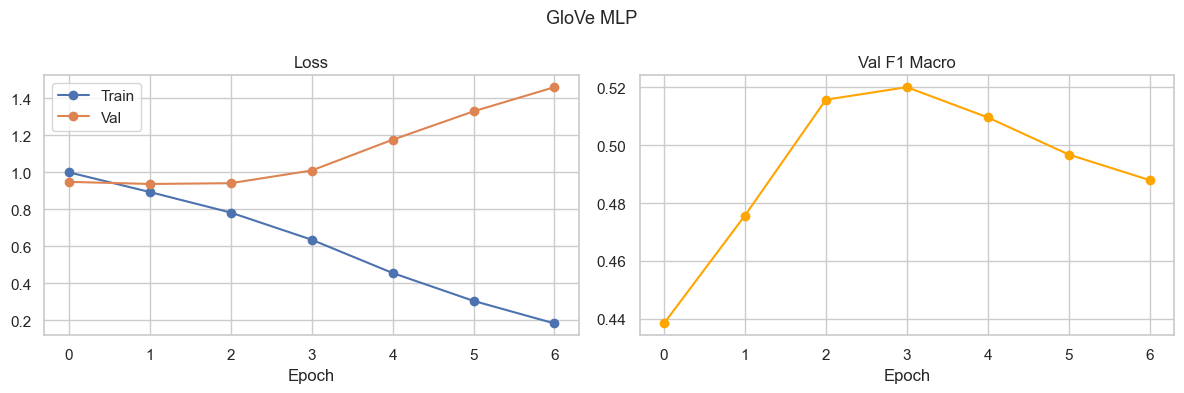


  GloVe MLP | TEST
  Accuracy      : 0.5535
  F1 (macro)    : 0.5275
  F1 (weighted) : 0.5415

              precision    recall  f1-score   support

         CAG       0.52      0.38      0.44       625
         NAG       0.60      0.75      0.66       727
         OAG       0.49      0.47      0.48       395

    accuracy                           0.55      1747
   macro avg       0.54      0.53      0.53      1747
weighted avg       0.55      0.55      0.54      1747



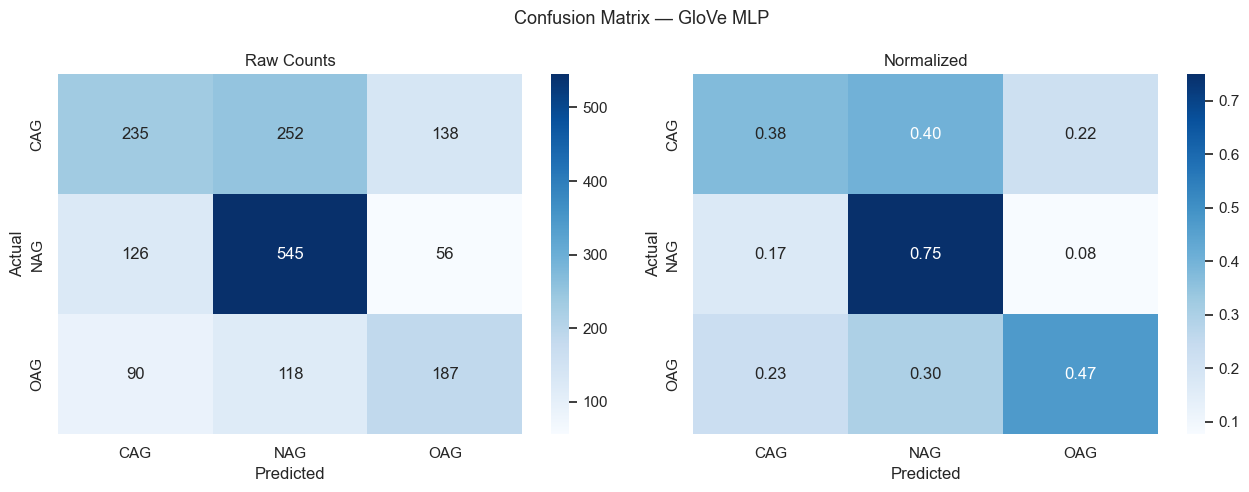

In [21]:
# ── 8.3 Train EmbeddingMLP ────────────────────────────────────────────────────
set_seed(CFG["seed"])
mlp_model = EmbeddingMLP(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    hidden_dim=256,
    dropout=CFG["dropout"]
)
print(f"MLP params: {sum(p.numel() for p in mlp_model.parameters()):,}")

mlp_history = train_model(
    mlp_model, loader_train, loader_val,
    model_name="GloVe MLP",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(mlp_history, "GloVe MLP")

mlp_preds = predict(mlp_model, loader_test, CFG["device"])
evaluate_clf("GloVe MLP", y_test, mlp_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, mlp_preds, "GloVe MLP", le)

TextCNN params: 2,635,039
Epoch   1/20 | tr_loss=0.9891 | va_loss=0.9368 | val_f1=0.4707 | 2.1s ✓  <-- new best
Epoch   2/20 | tr_loss=0.8427 | va_loss=0.9188 | val_f1=0.5147 | 1.8s ✓  <-- new best
Epoch   3/20 | tr_loss=0.6973 | va_loss=0.9320 | val_f1=0.5185 | 1.7s ✓  <-- new best
Epoch   4/20 | tr_loss=0.5020 | va_loss=1.0063 | val_f1=0.5151 | 1.7s
Epoch   5/20 | tr_loss=0.3083 | va_loss=1.1678 | val_f1=0.4964 | 1.7s
Epoch   6/20 | tr_loss=0.1583 | va_loss=1.2790 | val_f1=0.4986 | 1.7s
Early stopping triggered at epoch 6.
Restored best checkpoint | val_f1=0.5185 | path=models/GloVe_CNN/best.pt
Training complete.


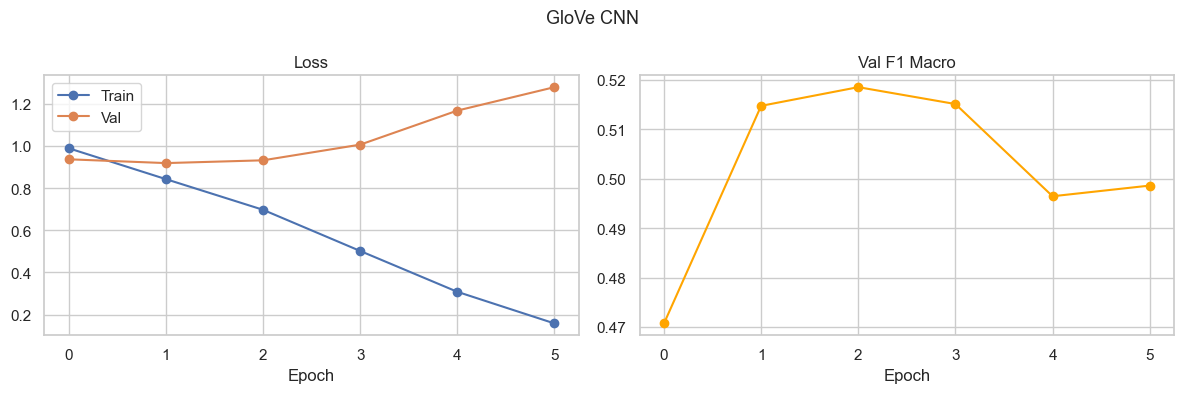


  GloVe CNN | TEST
  Accuracy      : 0.5592
  F1 (macro)    : 0.5268
  F1 (weighted) : 0.5473

              precision    recall  f1-score   support

         CAG       0.51      0.45      0.48       625
         NAG       0.60      0.76      0.67       727
         OAG       0.54      0.36      0.43       395

    accuracy                           0.56      1747
   macro avg       0.55      0.52      0.53      1747
weighted avg       0.55      0.56      0.55      1747



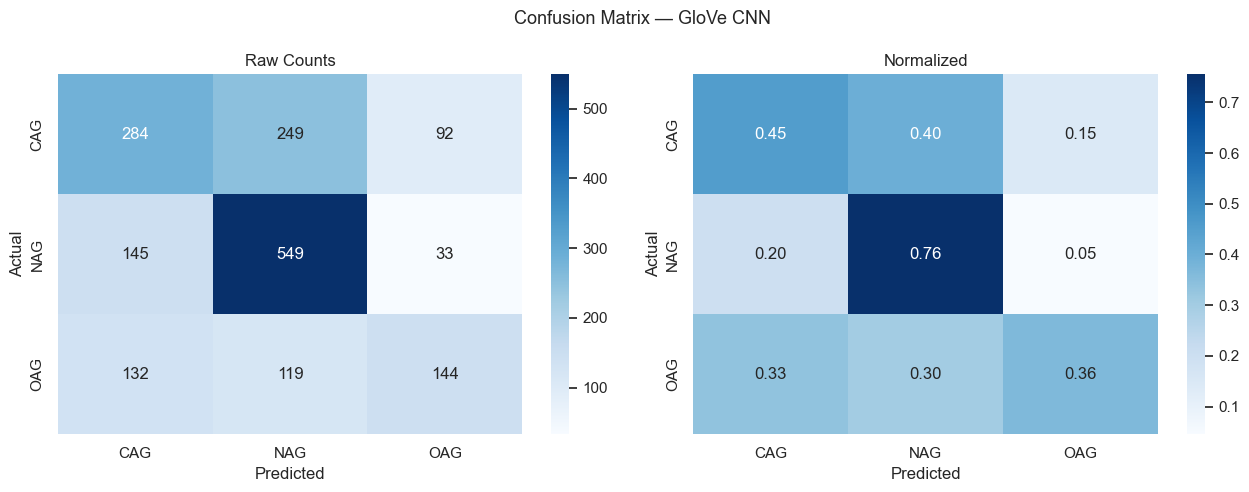

In [22]:
# ── 8.4 Train TextCNN ────────────────────────────────────────────────────────
set_seed(CFG["seed"])
cnn_model = TextCNN(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    num_filters=CFG["cnn_num_filters"],
    kernel_sizes=CFG["cnn_kernel_sizes"],
    dropout=CFG["dropout"]
)
print(f"TextCNN params: {sum(p.numel() for p in cnn_model.parameters()):,}")

cnn_history = train_model(
    cnn_model, loader_train, loader_val,
    model_name="GloVe CNN",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(cnn_history, "GloVe CNN")

cnn_preds = predict(cnn_model, loader_test, CFG["device"])
evaluate_clf("GloVe CNN", y_test, cnn_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, cnn_preds, "GloVe CNN", le)

---
# SECTION 9 — Recurrent Models (BiLSTM / BiGRU)

**BiLSTM with additive attention** — captures long-range dependencies.  
Swap `nn.LSTM` → `nn.GRU` in the constructor for a lighter BiGRU.

In [23]:
# ── 9.1 Additive Attention ────────────────────────────────────────────────────
class AdditiveAttention(nn.Module):
    """
    Computes a weighted average over LSTM hidden states.
    Weights are learned via a single linear layer + softmax.
    Padding positions are masked out before softmax.
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, h, mask=None):
        scores = self.attn(h).squeeze(-1)                       # (B, L)
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1)                  # (B, L)
        context = (weights.unsqueeze(-1) * h).sum(dim=1)        # (B, H)
        return context, weights


# ── 9.2 BiLSTM + Attention ────────────────────────────────────────────────────
class BiLSTMAttention(nn.Module):
    """
    Bidirectional LSTM with additive attention for text classification.

    Parameters
    ----------
    embedding_matrix : np.ndarray, shape (vocab_size, embed_dim)
    num_classes      : number of output classes
    hidden_dim       : LSTM hidden state size per direction
    num_layers       : number of stacked LSTM layers
    dropout          : dropout probability
    freeze_emb       : freeze pre-trained embeddings during training
    """
    def __init__(self, embedding_matrix: np.ndarray, num_classes: int,
                 hidden_dim: int = 128, num_layers: int = 2,
                 dropout: float = 0.3, freeze_emb: bool = False):
        super().__init__()
        _, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_emb, padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attention = AdditiveAttention(hidden_dim * 2)   # *2 for bidirectional
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        mask = (x != 0)                              # (B, L) True = real token
        emb  = self.dropout(self.embedding(x))       # (B, L, D)
        h, _ = self.lstm(emb)                        # (B, L, 2*H)
        ctx, _ = self.attention(h, mask)             # (B, 2*H)
        return self.fc(self.dropout(ctx))


print("BiLSTMAttention architecture defined.")

BiLSTMAttention architecture defined.


BiLSTM params: 3,150,111
Epoch   1/20 | tr_loss=0.9828 | va_loss=0.9415 | val_f1=0.4271 | 9.7s ✓  <-- new best
Epoch   2/20 | tr_loss=0.8990 | va_loss=0.9110 | val_f1=0.5113 | 9.3s ✓  <-- new best
Epoch   3/20 | tr_loss=0.8122 | va_loss=0.8970 | val_f1=0.5354 | 9.3s ✓  <-- new best
Epoch   4/20 | tr_loss=0.6799 | va_loss=0.9569 | val_f1=0.5256 | 9.4s
Epoch   5/20 | tr_loss=0.5126 | va_loss=1.1600 | val_f1=0.5086 | 9.6s
Epoch   6/20 | tr_loss=0.3566 | va_loss=1.2590 | val_f1=0.5058 | 9.7s
Early stopping triggered at epoch 6.
Restored best checkpoint | val_f1=0.5354 | path=models/GloVe_BiLSTM/best.pt
Training complete.


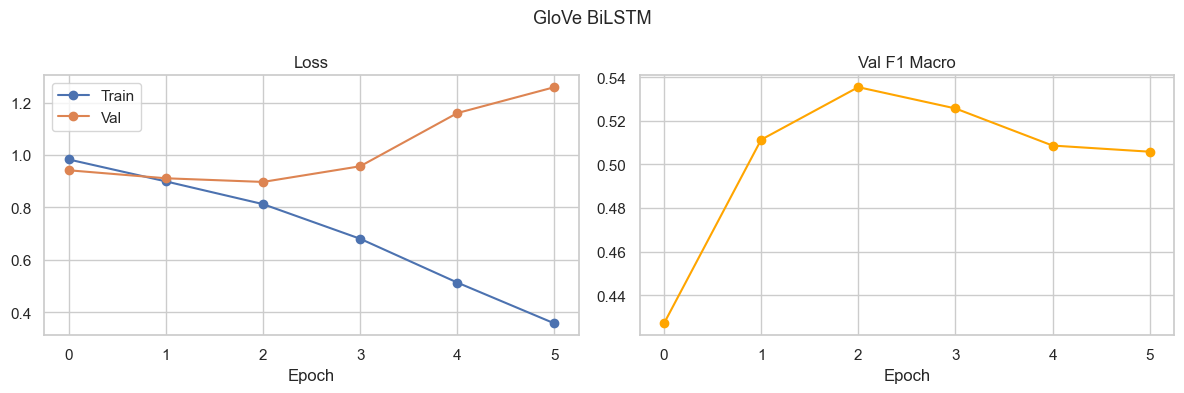


  GloVe BiLSTM | TEST
  Accuracy      : 0.5529
  F1 (macro)    : 0.5310
  F1 (weighted) : 0.5500

              precision    recall  f1-score   support

         CAG       0.47      0.53      0.50       625
         NAG       0.64      0.66      0.65       727
         OAG       0.52      0.38      0.44       395

    accuracy                           0.55      1747
   macro avg       0.54      0.53      0.53      1747
weighted avg       0.55      0.55      0.55      1747



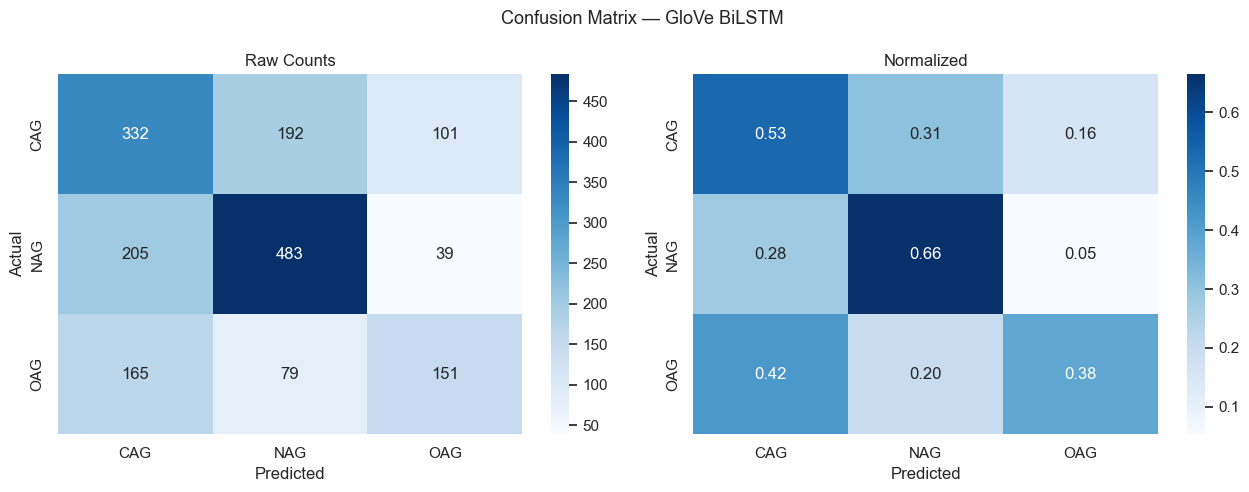

In [24]:
# ── 9.3 Train BiLSTM ──────────────────────────────────────────────────────────
set_seed(CFG["seed"])
bilstm_model = BiLSTMAttention(
    embedding_matrix=embedding_matrix,
    num_classes=CFG["num_labels"],
    hidden_dim=CFG["lstm_hidden_dim"],
    num_layers=CFG["lstm_num_layers"],
    dropout=CFG["dropout"]
)
print(f"BiLSTM params: {sum(p.numel() for p in bilstm_model.parameters()):,}")

lstm_history = train_model(
    bilstm_model, loader_train, loader_val,
    model_name="GloVe BiLSTM",
    epochs=CFG["dl_epochs"], lr=CFG["dl_lr"],
    patience=CFG["dl_patience"], device=CFG["device"]
)
plot_history(lstm_history, "GloVe BiLSTM")

bilstm_preds = predict(bilstm_model, loader_test, CFG["device"])
evaluate_clf("GloVe BiLSTM", y_test, bilstm_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, bilstm_preds, "GloVe BiLSTM", le)

---
# SECTION 10 — Transformer Fine-Tuning

Uses HuggingFace `Trainer` with early stopping on `f1_macro`.  
Input: `text_raw` (minimally cleaned) — the subword tokenizer handles the rest.

In [25]:
# ── 10.1 HuggingFace Dataset ──────────────────────────────────────────────────
class HFTextDataset(Dataset):
    """
    PyTorch Dataset wrapping a HuggingFace tokenizer for classification.
    Compatible with HF Trainer and standard DataLoader.

    Parameters
    ----------
    texts     : list/array of raw strings
    labels    : encoded integer class indices
    tokenizer : HuggingFace tokenizer
    max_len   : maximum token length
    """
    def __init__(self, texts, labels, tokenizer, max_len: int = 256):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_len, return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


# ── 10.2 Compute Metrics for HF Trainer ──────────────────────────────────────
def compute_metrics(eval_pred) -> dict:
    """
    Passed to HuggingFace Trainer. Returns F1-macro and accuracy.
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "accuracy": accuracy_score(labels, preds)
    }


print("HF Dataset and compute_metrics ready.")

HF Dataset and compute_metrics ready.


In [26]:
# ── 10.3 Tokeniser & Datasets ─────────────────────────────────────────────────
trf_tokenizer = AutoTokenizer.from_pretrained(CFG["trf_model"])

trf_ds_train = HFTextDataset(X_train_raw, y_train, trf_tokenizer, CFG["max_len"])
trf_ds_val   = HFTextDataset(X_val_raw,   y_val,   trf_tokenizer, CFG["max_len"])
trf_ds_test  = HFTextDataset(X_test_raw,  y_test,  trf_tokenizer, CFG["max_len"])

print(f"Train HF dataset: {len(trf_ds_train)} | "
      f"Val: {len(trf_ds_val)} | Test: {len(trf_ds_test)}")

INFO:httpx:HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


Train HF dataset: 8151 | Val: 1747 | Test: 1747


In [27]:
# ── 10.4 Model + Trainer ──────────────────────────────────────────────────────
out_dir = CFG["model_dir"] / "transformer"
out_dir.mkdir(parents=True, exist_ok=True)

trf_model = AutoModelForSequenceClassification.from_pretrained(
    CFG["trf_model"],
    num_labels=CFG["num_labels"],
    problem_type="single_label_classification",
    from_tf=False,
)

training_args = TrainingArguments(
    output_dir=str(out_dir),
    num_train_epochs=CFG["epochs"],
    per_device_train_batch_size=CFG["batch_size"],
    per_device_eval_batch_size=CFG["batch_size"],
    learning_rate=CFG["lr"],
    warmup_ratio=0.06,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_dir=str(CFG["log_dir"]),
    logging_strategy="epoch",
    report_to="tensorboard",

    fp16=torch.cuda.is_available(),
    seed=CFG["seed"],
)

trainer = Trainer(
    model=trf_model,
    args=training_args,
    train_dataset=trf_ds_train,
    eval_dataset=trf_ds_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

last_ckpt = get_last_checkpoint(str(out_dir))
print("Last checkpoint:", last_ckpt)

trainer.train(resume_from_checkpoint=last_ckpt if last_ckpt is not None else None)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

Last checkpoint: None


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.958692,0.856452,0.576327,0.594161
2,0.767994,0.872697,0.580294,0.593589
3,0.550755,0.954508,0.581776,0.595306
4,0.351589,1.160999,0.591697,0.607899
5,0.237044,1.321510,0.589715,0.602748


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2550, training_loss=0.5732147545908012, metrics={'train_runtime': 2350.2489, 'train_samples_per_second': 17.341, 'train_steps_per_second': 1.085, 'total_flos': 5361593669752320.0, 'train_loss': 0.5732147545908012, 'epoch': 5.0})

In [28]:
hist = trainer.state.log_history

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
json_path = CFG["log_dir"] / f"trainer_log_history_{ts}.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(hist, f, ensure_ascii=False, indent=2)

df_hist = pd.DataFrame(hist)
csv_path = CFG["log_dir"] / f"trainer_log_history_{ts}.csv"
df_hist.to_csv(csv_path, index=False)

print("Saved:", json_path, csv_path)
display(df_hist.tail(20))

Saved: logs/trainer_log_history_20260222_124054.json logs/trainer_log_history_20260222_124054.csv


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_f1_macro,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.958692,8.331271,1.702962e-05,1.0,510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,510,0.856452,0.576327,0.594161,26.6503,65.553,4.128,NaN,NaN,NaN,NaN,NaN
2,0.767994,16.796864,1.277430e-05,2.0,1020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,1020,0.872697,0.580294,0.593589,26.3406,66.324,4.176,NaN,NaN,NaN,NaN,NaN
4,0.550755,11.735625,8.518982e-06,3.0,1530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,1530,0.954508,0.581776,0.595306,26.3766,66.233,4.170,NaN,NaN,NaN,NaN,NaN
6,0.351589,25.036587,4.263663e-06,4.0,2040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,2040,1.160999,0.591697,0.607899,26.3461,66.310,4.175,NaN,NaN,NaN,NaN,NaN
8,0.237044,11.530713,8.343763e-09,5.0,2550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,5.0,2550,1.321510,0.589715,0.602748,26.3245,66.364,4.179,NaN,NaN,NaN,NaN,NaN



  BERT Fine-tune | VAL
  Accuracy      : 0.6068
  F1 (macro)    : 0.5907
  F1 (weighted) : 0.6060

              precision    recall  f1-score   support

         CAG       0.53      0.56      0.54       625
         NAG       0.70      0.71      0.70       728
         OAG       0.56      0.49      0.53       394

    accuracy                           0.61      1747
   macro avg       0.60      0.59      0.59      1747
weighted avg       0.61      0.61      0.61      1747


  BERT Fine-tune | TEST
  Accuracy      : 0.5861
  F1 (macro)    : 0.5717
  F1 (weighted) : 0.5862

              precision    recall  f1-score   support

         CAG       0.49      0.54      0.52       625
         NAG       0.69      0.69      0.69       727
         OAG       0.56      0.47      0.51       395

    accuracy                           0.59      1747
   macro avg       0.58      0.57      0.57      1747
weighted avg       0.59      0.59      0.59      1747



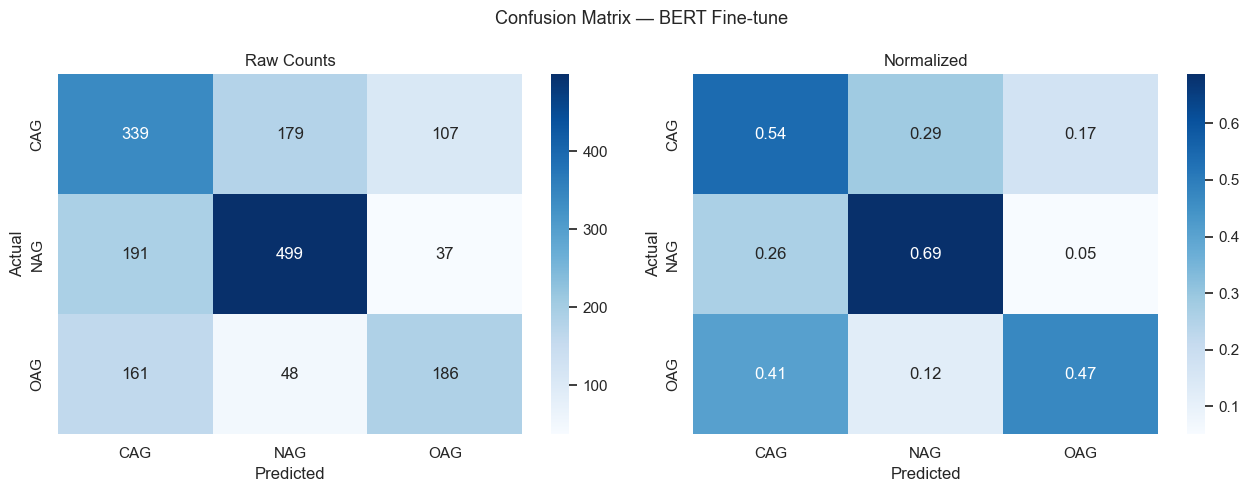

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Transformer model saved.


In [29]:
# ── 10.5 Evaluate Transformer ─────────────────────────────────────────────────
trf_val_output  = trainer.predict(trf_ds_val)
trf_test_output = trainer.predict(trf_ds_test)

trf_val_preds  = np.argmax(trf_val_output.predictions,  axis=1)
trf_test_preds = np.argmax(trf_test_output.predictions, axis=1)

evaluate_clf("BERT Fine-tune", y_val,  trf_val_preds,  label_encoder=le, split="val")
evaluate_clf("BERT Fine-tune", y_test, trf_test_preds, label_encoder=le)
plot_confusion_matrix_clf(y_test, trf_test_preds, "BERT Fine-tune", le)

# Save fine-tuned model & tokenizer
trainer.save_model(str(CFG["model_dir"] / "transformer_best"))
trf_tokenizer.save_pretrained(str(CFG["model_dir"] / "transformer_best"))
print("Transformer model saved.")

---
# SECTION 11 — Model Comparison & Results Table

In [30]:
# ── 11.1 Results Table ────────────────────────────────────────────────────────
print_results_table()


Model                                    accuracy      f1_macro   f1_weighted
Majority Baseline | test                   0.4161        0.1959        0.2446
TF-IDF + LogReg | val                      0.5610        0.5467        0.5616
TF-IDF + LogReg | test                     0.5667        0.5562        0.5674
TF-IDF + XGBoost | val                     0.5392        0.5061        0.5285
TF-IDF + XGBoost | test                    0.5570        0.5241        0.5455
GloVe MLP | test                           0.5535        0.5275        0.5415
GloVe CNN | test                           0.5592        0.5268        0.5473
GloVe BiLSTM | test                        0.5529        0.5310        0.5500
BERT Fine-tune | val                       0.6068        0.5907        0.6060
BERT Fine-tune | test                      0.5861        0.5717        0.5862


In [31]:
# ── 11.2 Results as DataFrame ─────────────────────────────────────────────────
df_results = (
    pd.DataFrame(RESULTS)
    .T
    .rename_axis("Model | Split")
    .sort_values("f1_macro", ascending=False)
)
display(df_results.round(4))

df_results.to_csv(CFG["output_dir"] / f"results_{CFG['task']}.csv")
print("Results saved.")

,accuracy,f1_macro,f1_weighted
Model | Split,,,
BERT Fine-tune | val,0.6068,0.5907,0.6060
BERT Fine-tune | test,0.5861,0.5717,0.5862
TF-IDF + LogReg | test,0.5667,0.5562,0.5674
TF-IDF + LogReg | val,0.5610,0.5467,0.5616
GloVe BiLSTM | test,0.5529,0.5310,0.5500
GloVe MLP | test,0.5535,0.5275,0.5415
GloVe CNN | test,0.5592,0.5268,0.5473
TF-IDF + XGBoost | test,0.5570,0.5241,0.5455
TF-IDF + XGBoost | val,0.5392,0.5061,0.5285


Results saved.


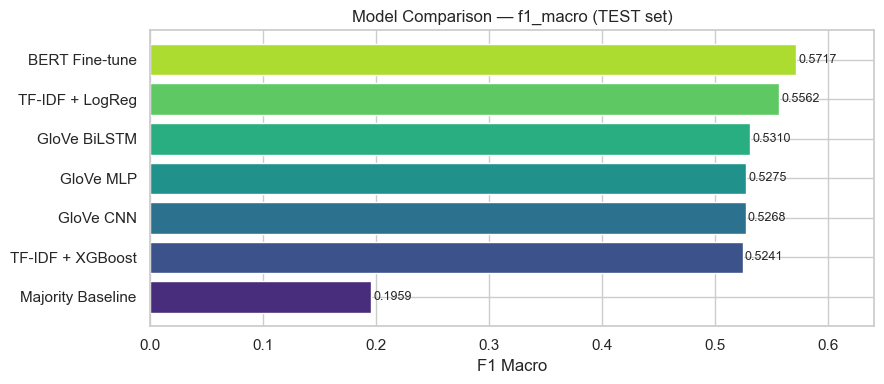

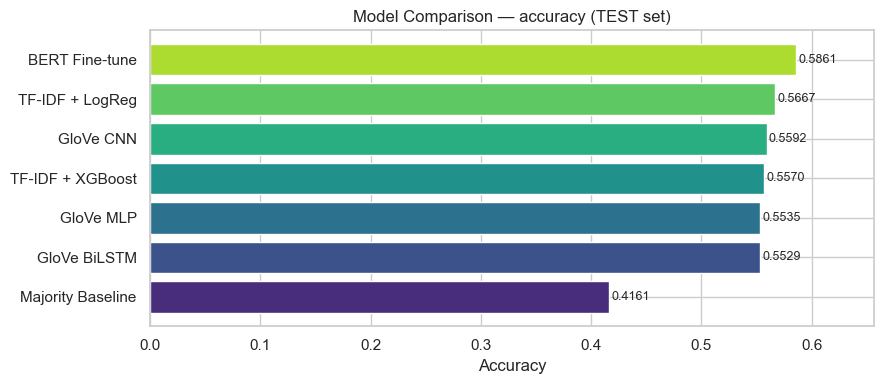

In [32]:
# ── 11.3 Bar Chart Comparison ─────────────────────────────────────────────────
def plot_model_comparison(results: dict, metric: str = "f1_macro",
                          split: str = "test"):
    """
    Horizontal bar chart comparing all models on `metric` for the given `split`.

    Parameters
    ----------
    results : RESULTS dict
    metric  : column to plot (e.g. "f1_macro", "accuracy")
    split   : "test" or "val" — filters RESULTS entries
    """
    filtered = {
        k.replace(f" | {split}", ""): v[metric]
        for k, v in results.items()
        if split in k and metric in v
    }
    if not filtered:
        print(f"No results for split='{split}', metric='{metric}'.")
        return

    names  = list(filtered.keys())
    values = list(filtered.values())
    order  = np.argsort(values)

    fig, ax = plt.subplots(figsize=(9, max(4, len(names) * 0.55)))
    bars = ax.barh(
        [names[i] for i in order],
        [values[i] for i in order],
        color=sns.color_palette("viridis", len(names))
    )
    for bar, val in zip(bars, [values[i] for i in order]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)

    ax.set_xlabel(metric.replace("_", " ").title())
    ax.set_title(f"Model Comparison — {metric} ({split.upper()} set)")
    ax.set_xlim(0, min(1.05, max(values) * 1.12))
    plt.tight_layout()
    plt.savefig(CFG["output_dir"] / f"comparison_{metric}_{split}.png", dpi=120)
    plt.show()


plot_model_comparison(RESULTS, metric="f1_macro", split="test")
plot_model_comparison(RESULTS, metric="accuracy", split="test")

In [33]:
# ── 11.4 Error Analysis — Top Misclassified Samples ──────────────────────────
def error_analysis(df_split: pd.DataFrame, y_true, y_pred,
                   label_encoder=None, n: int = 10) -> pd.DataFrame:
    """
    Returns a DataFrame of the top-n misclassified samples.

    Parameters
    ----------
    df_split      : DataFrame for the relevant split (e.g. df_test)
    y_true, y_pred: encoded labels
    label_encoder : to decode label names
    n             : number of examples to display
    """
    err_mask = y_true != y_pred
    df_err   = df_split[err_mask].copy()
    df_err["y_true"] = y_true[err_mask]
    df_err["y_pred"] = y_pred[err_mask]

    if label_encoder is not None:
        df_err["true_label"] = label_encoder.inverse_transform(df_err["y_true"])
        df_err["pred_label"] = label_encoder.inverse_transform(df_err["y_pred"])
        cols = [CFG["text_col"], "true_label", "pred_label"]
    else:
        cols = [CFG["text_col"], "y_true", "y_pred"]

    return df_err[cols].head(n)


print("=== Error Analysis — BERT Fine-tune ===")
display(error_analysis(df_test, y_test, trf_test_preds, le, n=10))

=== Error Analysis — BERT Fine-tune ===


,text,true_label,pred_label
1,Whom u r addressing to....?? Be specific,CAG,NAG
3,There is a bigger scam all over India in issui...,NAG,CAG
4,Not good job.....this guis creating a problem ...,CAG,NAG
5,"Save peoples madam, they will saves all animals",NAG,CAG
6,We will continue to eat beef irrespective of c...,OAG,CAG
8,"Q1) Are GDP data fudged?\n\n- Yes, they are. T...",CAG,NAG
11,terrible rule. Some people have a passion for ...,OAG,CAG
13,"What's d point shut off fuel on Sunday then,, ...",NAG,CAG
14,No work make this men a nonsense to our society,CAG,OAG
17,Why am i watching this ..cuz tht reporter is c...,NAG,CAG


---
# SECTION 12 — Saving, Logging & Final Report

In [34]:
# ── 12.1 Save All Artefacts ───────────────────────────────────────────────────
def save_artefacts():
    """Saves CFG, RESULTS, label encoder and vocab to disk."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")

    # CFG (Path objects → str)
    cfg_serializable = {k: str(v) if isinstance(v, Path) else v
                        for k, v in CFG.items()}
    with open(CFG["output_dir"] / f"cfg_{timestamp}.json", "w") as f:
        json.dump(cfg_serializable, f, indent=2, default=str)

    # RESULTS
    with open(CFG["output_dir"] / f"results_{timestamp}.json", "w") as f:
        json.dump(RESULTS, f, indent=2)

    # Label encoder & vocab
    joblib.dump(le,    CFG["model_dir"] / "label_encoder.pkl")
    joblib.dump(vocab, CFG["model_dir"] / "vocab.pkl")

    print(f"Artefacts saved  →  {CFG['output_dir']}  |  {CFG['model_dir']}")

save_artefacts()

Artefacts saved  →  outputs  |  models


In [35]:
# ── 12.2 Weights & Biases Experiment Tracking ─────────────────────────────────
# pip install wandb

# import wandb
# wandb.init(
#     project=CFG["task"],
#     config=CFG,
#     name=f"run_{datetime.now().strftime('%m%d_%H%M')}"
# )
# Then set report_to="wandb" in TrainingArguments.

In [36]:
# ── 12.3 Statistical Significance Test (McNemar) ──────────────────────────────
# Before claiming Model A > Model B, verify with McNemar's test.
# p-value > 0.05 → difference is NOT statistically significant.

# from statsmodels.stats.contingency_tables import mcnemar

# correct_a = (bilstm_preds   == y_test)
# correct_b = (trf_test_preds == y_test)
# table = np.array([
#     [(correct_a & correct_b).sum(),  (~correct_a & correct_b).sum()],
#     [(correct_a & ~correct_b).sum(), (~correct_a & ~correct_b).sum()]
# ])
# result = mcnemar(table, exact=False)
# print(f"McNemar p-value: {result.pvalue:.4f}")
# print(f"Significant difference: {result.pvalue < 0.05}")

In [37]:
# ── 12.4 Data Augmentation (Back-Translation) ──────────────────────────────────
# Useful when one class is heavily under-represented (e.g. abuse class).
# pip install transformers sentencepiece

# from transformers import MarianMTModel, MarianTokenizer

# def back_translate(texts, src_lang="Helsinki-NLP/opus-mt-en-fr",
#                           tgt_lang="Helsinki-NLP/opus-mt-fr-en"):
#     tok_fwd  = MarianTokenizer.from_pretrained(src_lang)
#     mdl_fwd  = MarianMTModel.from_pretrained(src_lang)
#     fr_ids   = mdl_fwd.generate(**tok_fwd(texts, return_tensors="pt", padding=True, truncation=True))
#     fr_texts = tok_fwd.batch_decode(fr_ids, skip_special_tokens=True)
#     tok_bwd  = MarianTokenizer.from_pretrained(tgt_lang)
#     mdl_bwd  = MarianMTModel.from_pretrained(tgt_lang)
#     en_ids   = mdl_bwd.generate(**tok_bwd(fr_texts, return_tensors="pt", padding=True, truncation=True))
#     return tok_bwd.batch_decode(en_ids, skip_special_tokens=True)

In [38]:
# ── 12.5 K-Fold CV for Deep Models (small datasets < 5k) ─────────────────────

# fold_scores = []
# for fold, (train_idx, val_idx) in enumerate(cv.split(df, df["label_enc"])):
#     print(f"\n── Fold {fold+1}/{CFG['cv_folds']} ──")
#     df_f_train = df.iloc[train_idx].reset_index(drop=True)
#     df_f_val   = df.iloc[val_idx].reset_index(drop=True)
#     # ... rebuild sequences, loaders, reinitialise model, train, evaluate ...
#     fold_scores.append(fold_f1)
# print(f"CV F1-macro: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

In [39]:
# ── 12.6 ONNX Export (portable inference) ────────────────────────────────────

# dummy_input = torch.zeros(1, CFG["max_seq_len"], dtype=torch.long).to(CFG["device"])
# cnn_model.eval()
# torch.onnx.export(
#     cnn_model, dummy_input,
#     CFG["model_dir"] / "TextCNN.onnx",
#     input_names=["input_ids"],
#     output_names=["logits"],
#     opset_version=14,
#     dynamic_axes={"input_ids": {0: "batch_size"}}
# )
# print("ONNX model saved.")

## What to change between notebooks

**CFG block**:

```python
"task"       → name of your specific task
"num_labels" → number of distinct classes
"trf_model"  → HuggingFace model checkpoint
"text_col"   → column name of the raw text in your dataset
"label_col"  → column name of the label in your dataset
```

\+ **hyperparameters / models architecture**

Data loading (Section 1), preprocessing (Section 2), splitting (Section 3),  
training loop (Section 7), and evaluation (Section 4) are **identical across all notebooks**.

In [40]:
# TESTING BEST MODEL

MODEL_PATH = str(CFG["model_dir"] / "transformer_best")

# Load once
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

@torch.no_grad()
def predict_one(text: str):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)

    outputs = model(**inputs)
    logits = outputs.logits

    probs = torch.softmax(logits, dim=-1)
    conf, pred_id = torch.max(probs, dim=-1)

    pred_id = int(pred_id.item())
    confidence = float(conf.item())

    # если есть label encoder
    if "le" in globals():
        pred_label = le.inverse_transform([pred_id])[0]
    else:
        pred_label = str(pred_id)

    return pred_label, confidence

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [41]:
label, conf = predict_one("You are a good person") # NAG = No Agression
print(f"Prediction: {label}")
print(f"Confidence: {conf:.4f}")

Prediction: NAG
Confidence: 0.9887


In [42]:
label, conf = predict_one("You are a motherfucker!") # OAG = Open Agression
print(f"Prediction: {label}")
print(f"Confidence: {conf:.4f}")

Prediction: OAG
Confidence: 0.9869


In [43]:
label, conf = predict_one("I hope people like you won't come to my country!") # CAG = Covered (hidden) Agression
print(f"Prediction: {label}")
print(f"Confidence: {conf:.4f}")

Prediction: CAG
Confidence: 0.5555
